In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pingouin as pg
from scikit_posthocs import posthoc_dunn
from statsmodels.stats.multitest import multipletests
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['font.size'] = 11

DATA_DIR = '../data'
INFO_ORDER = ['fixed_cost', 'dynamic_cost', 'none']
DVS = ['mean_investment', 'mean_confidence', 'mean_risk']

print('Imports ready')

Imports ready


In [2]:
participants    = pd.read_csv(f'{DATA_DIR}/participants.csv')
task_responses  = pd.read_csv(f'{DATA_DIR}/task_responses.csv')
confidence_risk = pd.read_csv(f'{DATA_DIR}/confidence_risk.csv')

task_responses['total_investment']   = pd.to_numeric(task_responses['total_investment'])
confidence_risk['confidence_rating'] = pd.to_numeric(confidence_risk['confidence_rating'])
confidence_risk['risk_rating']       = pd.to_numeric(confidence_risk['risk_rating'])

# Step 1.1 — Completed and not withdrawn
eligible = participants[
    (participants['completed'] == True) &
    (participants['withdrawn'] == False)
].copy()
print(f'After completed & not withdrawn: {len(eligible)}')

# Step 1.2 — Attention checks
# Task 3: correct = 2 (all conditions)
# Task 7: correct = 5 for e2/e3/e4/e5; correct = 4 for e1/e6
attn = (
    confidence_risk[confidence_risk['completed_after_task'].isin([3, 7])]
    [['participant_id', 'completed_after_task', 'attention_check_response']]
    .merge(eligible[['participant_id', 'experiment_key']], on='participant_id', how='inner')
    .copy()
)

def correct_answer(row):
    if row['completed_after_task'] == 3:
        return 2
    return 5 if row['experiment_key'] in {'e2', 'e3', 'e4', 'e5'} else 4

attn['correct'] = attn.apply(correct_answer, axis=1)
attn['passed']  = (
    pd.to_numeric(attn['attention_check_response'], errors='coerce') == attn['correct']
)

attn_wide = (
    attn.pivot_table(index='participant_id', columns='completed_after_task',
                     values='passed', aggfunc='first')
    .reset_index()
)
attn_wide.columns = ['participant_id', 'pass_task3', 'pass_task7']

failed_both = attn_wide[
    (attn_wide['pass_task3'] == False) & (attn_wide['pass_task7'] == False)
]['participant_id']
print(f'Excluding {len(failed_both)} participant(s) who failed both attention checks')

eligible = eligible[~eligible['participant_id'].isin(failed_both)].copy()
print(f'Final eligible N = {len(eligible)}  (expected: 223)')

# Step 1.3 — Condition assignment (do NOT use show_profit_loss/show_information from task_responses)
info_map = {
    'e1': 'fixed_cost', 'e2': 'dynamic_cost', 'e3': 'none',
    'e4': 'fixed_cost', 'e5': 'dynamic_cost', 'e6': 'none'
}
pl_map = {
    'e1': True, 'e2': True, 'e3': True,
    'e4': False, 'e5': False, 'e6': False
}
eligible['info_type'] = eligible['experiment_key'].map(info_map)
eligible['show_pl']   = eligible['experiment_key'].map(pl_map)

print('\nSample by condition:')
print(
    eligible.groupby(['experiment_key', 'info_type', 'show_pl'])
    .size().reset_index(name='n').to_string(index=False)
)

After completed & not withdrawn: 230
Excluding 7 participant(s) who failed both attention checks
Final eligible N = 223  (expected: 223)

Sample by condition:
experiment_key    info_type  show_pl  n
            e1   fixed_cost     True 35
            e2 dynamic_cost     True 37
            e3         none     True 38
            e4   fixed_cost    False 39
            e5 dynamic_cost    False 39
            e6         none    False 35


In [3]:
# Differential attrition check: confirm attention failures are not condition-specific
print('Attention check failures by experiment_key:')
fail_check = (
    attn[['participant_id', 'experiment_key']].drop_duplicates()
    .assign(failed_both=lambda d: d['participant_id'].isin(failed_both))
    .groupby(['experiment_key', 'failed_both'])
    .size().unstack(fill_value=0)
    .rename(columns={False: 'passed_at_least_one', True: 'failed_both'})
)
print(fail_check)
print('\nTotal excluded:', len(failed_both))

Attention check failures by experiment_key:
failed_both     passed_at_least_one  failed_both
experiment_key                                  
e1                               35            0
e2                               37            3
e3                               38            2
e4                               39            1
e5                               39            1
e6                               35            0

Total excluded: 7


In [4]:
valid_ids = set(eligible['participant_id'])
tr = task_responses[task_responses['participant_id'].isin(valid_ids)].copy()
cr = confidence_risk[confidence_risk['participant_id'].isin(valid_ids)].copy()

# mean_investment: mean of total_investment across 10 tasks
mean_inv = (
    tr.groupby('participant_id')['total_investment']
    .mean().reset_index()
    .rename(columns={'total_investment': 'mean_investment'})
)

# mean_confidence and mean_risk: mean across all 10 rows per participant.
# Attention-check rows (where attention_check_response is not null) still contain
# valid ratings — include all 10 rows in the mean.
mean_conf = (
    cr.groupby('participant_id')['confidence_rating']
    .mean().reset_index()
    .rename(columns={'confidence_rating': 'mean_confidence'})
)
mean_risk_agg = (
    cr.groupby('participant_id')['risk_rating']
    .mean().reset_index()
    .rename(columns={'risk_rating': 'mean_risk'})
)

df = (
    eligible[['participant_id', 'experiment_key', 'info_type', 'show_pl']]
    .merge(mean_inv,      on='participant_id')
    .merge(mean_conf,     on='participant_id')
    .merge(mean_risk_agg, on='participant_id')
)

assert df.shape[0] == 223, f'Expected 223, got {df.shape[0]}'
assert df.isnull().sum().sum() == 0, 'Unexpected missing values'
print(f'Analysis dataset: {df.shape[0]} participants × {df.shape[1]} columns')
print('\nDV distributions:')
print(df[DVS].describe().round(2))

Analysis dataset: 223 participants × 7 columns

DV distributions:
       mean_investment  mean_confidence  mean_risk
count           223.00           223.00     223.00
mean             80.91            56.71      47.06
std              25.79            19.49      19.27
min               3.20             0.00       4.30
25%              70.00            46.70      32.90
50%              94.50            57.70      48.50
75%              99.60            69.50      60.85
max             100.00           100.00     100.00


In [5]:
# Table: N, Mean, SD, Median per cell (info_type × show_pl)
for dv in DVS:
    sep = '=' * 60
    print(f'\n{sep}\nDV: {dv}\n{sep}')
    tbl = (
        df.groupby(['info_type', 'show_pl'])[dv]
        .agg(N='count', Mean='mean', SD='std', Median='median')
        .round(3)
    )
    print(tbl.to_string())


DV: mean_investment
                       N    Mean      SD  Median
info_type    show_pl                            
dynamic_cost False    39  83.862  24.251  94.000
             True     37  77.597  28.432  93.700
fixed_cost   False    39  78.915  24.568  92.894
             True     35  74.926  33.033  90.003
none         False    35  85.663  19.460  95.000
             True     38  84.311  23.182  99.999

DV: mean_confidence
                       N    Mean      SD  Median
info_type    show_pl                            
dynamic_cost False    39  62.662  20.650   63.10
             True     37  52.181  15.894   50.70
fixed_cost   False    39  61.662  16.448   63.00
             True     35  53.169  20.149   51.00
none         False    35  55.363  22.688   61.30
             True     38  54.434  19.185   55.45

DV: mean_risk
                       N    Mean      SD  Median
info_type    show_pl                            
dynamic_cost False    39  49.469  19.301    50.0
            

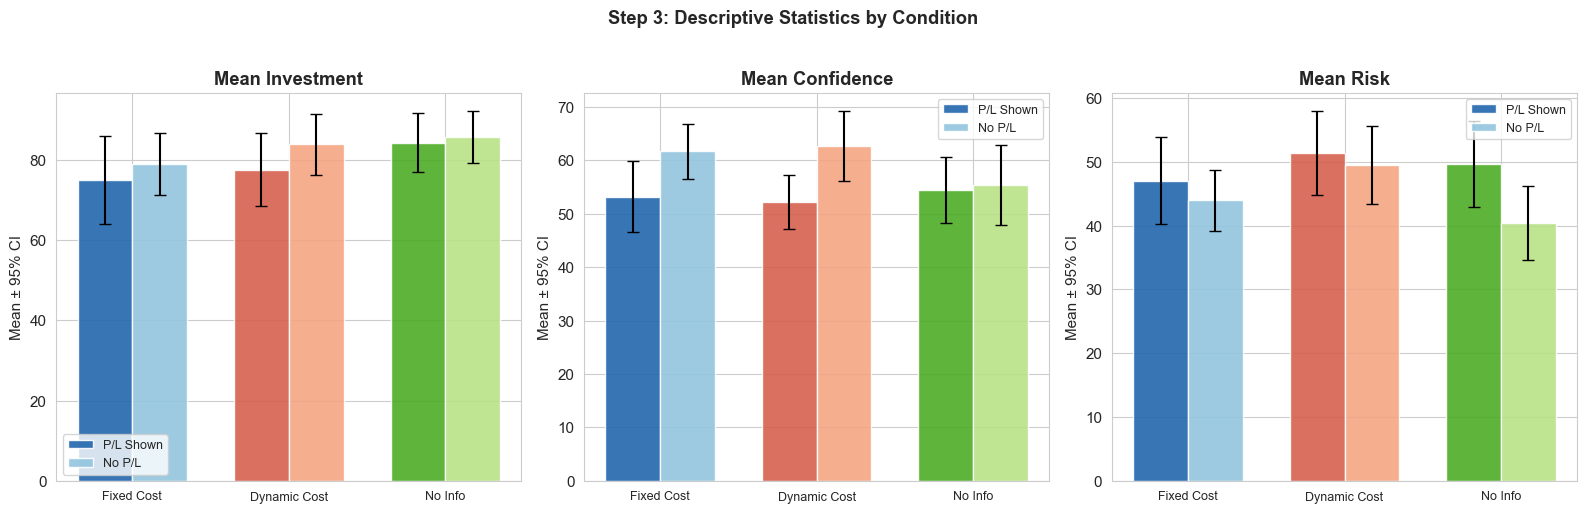

In [6]:
# Grouped bar charts with 95% CI (one per DV)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(3)
w = 0.35
XLABELS = ['Fixed Cost', 'Dynamic Cost', 'No Info']
c_shown = ['#2166AC', '#D6604D', '#4DAC26']
c_not   = ['#92C5DE', '#F4A582', '#B8E186']

for ax, dv in zip(axes, DVS):
    sdf = df.groupby(['info_type', 'show_pl'])[dv].agg(['mean', 'sem']).reset_index()
    sdf['ci95'] = sdf['sem'] * 1.96
    for pl_val, label, cols, offset in [
        (True,  'P/L Shown', c_shown, -w/2),
        (False, 'No P/L',    c_not,    w/2)
    ]:
        sub = sdf[sdf['show_pl'] == pl_val].set_index('info_type').reindex(INFO_ORDER)
        ax.bar(x + offset, sub['mean'], w, yerr=sub['ci95'],
               label=label, color=cols, capsize=4, alpha=0.9, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(XLABELS, fontsize=9)
    ax.set_title(dv.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('Mean \u00b1 95% CI')
    ax.legend(fontsize=9)

plt.suptitle('Step 3: Descriptive Statistics by Condition', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Shapiro-Wilk: mean_investment
  fixed_cost / P/L=Y                   n= 35  W=0.7332  p=0.0000  [FAIL]
  dynamic_cost / P/L=Y                 n= 37  W=0.7832  p=0.0000  [FAIL]
  none / P/L=Y                         n= 38  W=0.7244  p=0.0000  [FAIL]
  fixed_cost / P/L=N                   n= 39  W=0.7951  p=0.0000  [FAIL]
  dynamic_cost / P/L=N                 n= 39  W=0.6600  p=0.0000  [FAIL]
  none / P/L=N                         n= 35  W=0.7625  p=0.0000  [FAIL]
  → All cells normal: False


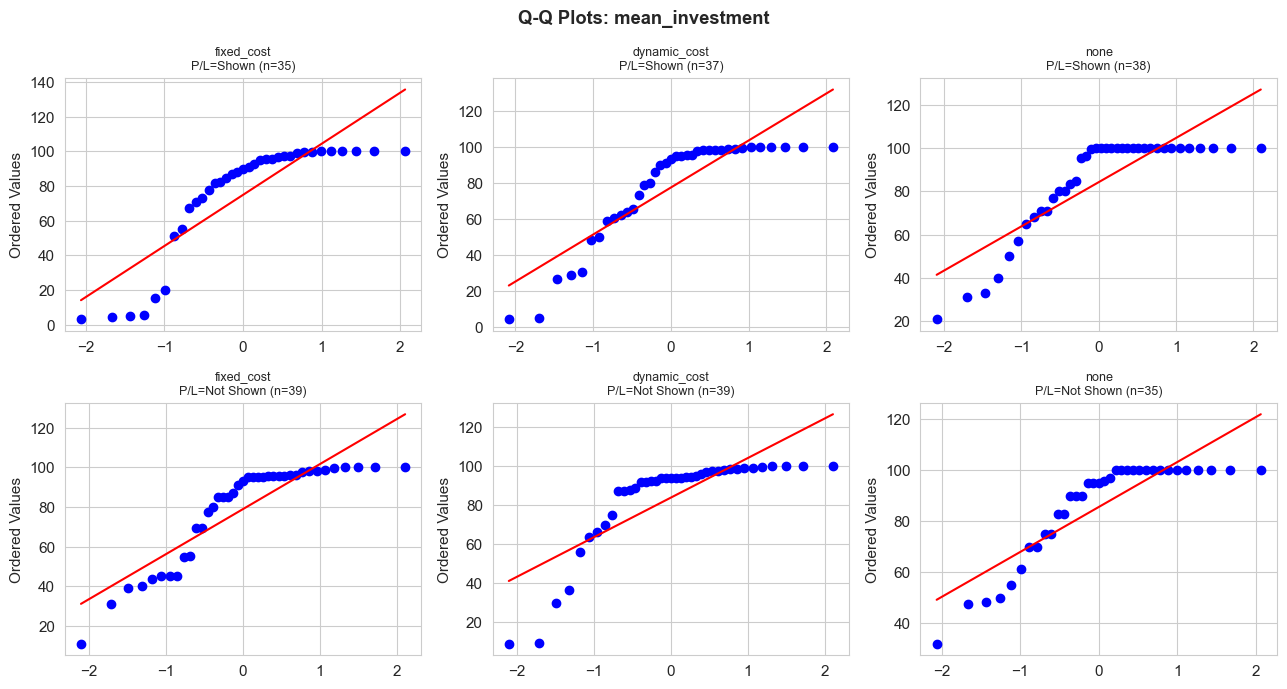


Shapiro-Wilk: mean_confidence
  fixed_cost / P/L=Y                   n= 35  W=0.9719  p=0.4979  [OK]
  dynamic_cost / P/L=Y                 n= 37  W=0.9818  p=0.7922  [OK]
  none / P/L=Y                         n= 38  W=0.9830  p=0.8215  [OK]
  fixed_cost / P/L=N                   n= 39  W=0.8760  p=0.0005  [FAIL]
  dynamic_cost / P/L=N                 n= 39  W=0.9186  p=0.0079  [FAIL]
  none / P/L=N                         n= 35  W=0.9567  p=0.1818  [OK]
  → All cells normal: False


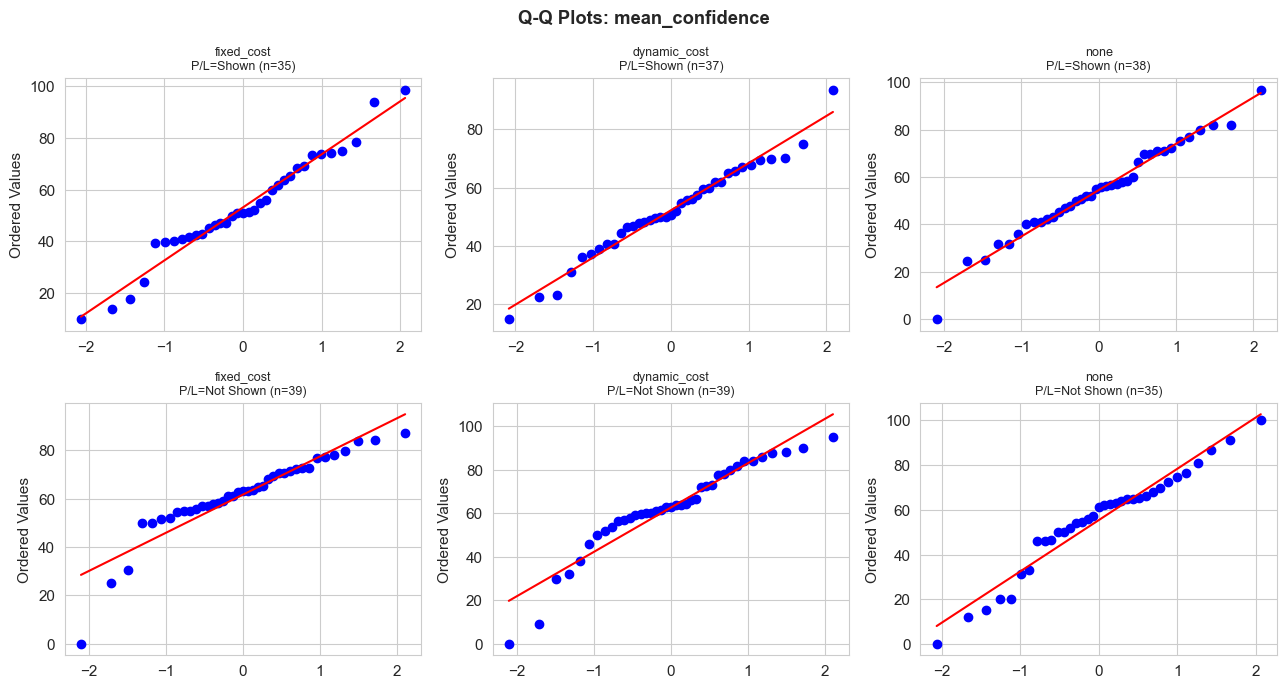


Shapiro-Wilk: mean_risk
  fixed_cost / P/L=Y                   n= 35  W=0.9610  p=0.2452  [OK]
  dynamic_cost / P/L=Y                 n= 37  W=0.9804  p=0.7465  [OK]
  none / P/L=Y                         n= 38  W=0.9876  p=0.9418  [OK]
  fixed_cost / P/L=N                   n= 39  W=0.9812  p=0.7463  [OK]
  dynamic_cost / P/L=N                 n= 39  W=0.9703  p=0.3834  [OK]
  none / P/L=N                         n= 35  W=0.9779  p=0.6904  [OK]
  → All cells normal: True


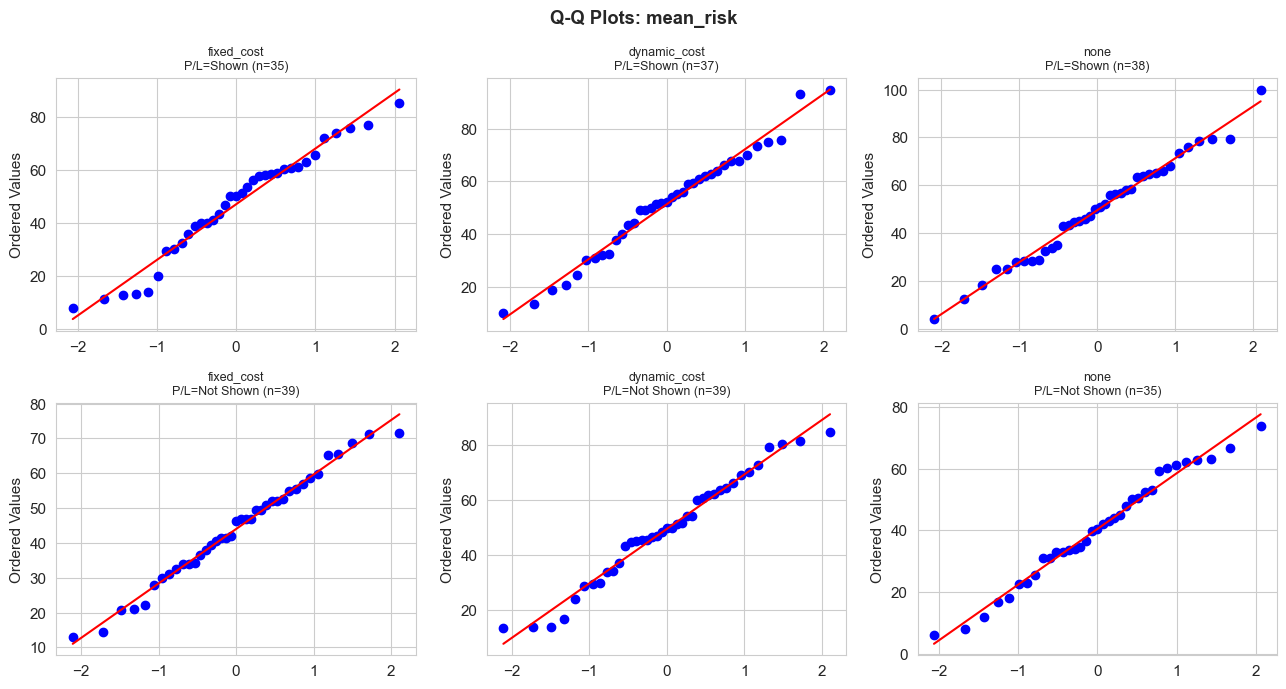

In [7]:
# Shapiro-Wilk per cell + Q-Q plots
# Layout: rows = show_pl (True/False), cols = info_type (fixed/dynamic/none)
normality_ok = {}

for dv in DVS:
    sep = '=' * 65
    print(f'\n{sep}\nShapiro-Wilk: {dv}\n{sep}')
    all_normal = True

    fig, axes = plt.subplots(2, 3, figsize=(13, 7))
    fig.suptitle(f'Q-Q Plots: {dv}', fontweight='bold')

    for pl_idx, pl_val in enumerate([True, False]):
        for it_idx, it in enumerate(INFO_ORDER):
            data = df[(df['info_type'] == it) & (df['show_pl'] == pl_val)][dv].dropna()
            W, p = stats.shapiro(data)
            status = 'OK' if p > 0.05 else 'FAIL'
            if p <= 0.05:
                all_normal = False
            label = f"{it} / P/L={'Y' if pl_val else 'N'}"
            print(f'  {label:35s}  n={len(data):3d}  W={W:.4f}  p={p:.4f}  [{status}]')

            ax = axes[pl_idx, it_idx]
            stats.probplot(data, dist='norm', plot=ax)
            ax.set_title(f"{it}\nP/L={'Shown' if pl_val else 'Not Shown'} (n={len(data)})", fontsize=9)
            ax.set_xlabel('')

    normality_ok[dv] = all_normal
    print(f'  \u2192 All cells normal: {all_normal}')
    plt.tight_layout()
    plt.show()

In [8]:
# 4.2 Levene's test across all 6 cells per DV
# 4.3 Decision table
levene_ok = {}
decision   = {}

print('Levene\'s test (homogeneity of variance across 6 cells):\n')
for dv in DVS:
    cell_data = [
        df[(df['info_type'] == it) & (df['show_pl'] == pl)][dv].dropna()
        for it in INFO_ORDER for pl in [True, False]
    ]
    lev_F, lev_p = stats.levene(*cell_data)
    levene_ok[dv] = lev_p > 0.05
    print(f'  {dv}: F={lev_F:.4f}, p={lev_p:.4f}  [{"equal var" if levene_ok[dv] else "UNEQUAL var"}]')

print('\n--- Decision Table ---')
for dv in DVS:
    if dv == 'mean_investment':
        dec = 'Kruskal-Wallis (pre-registered: right-skewed)'
    elif not normality_ok[dv]:
        dec = 'Kruskal-Wallis (normality fallback — deviation from pre-registration)'
    elif not levene_ok[dv]:
        dec = "Welch's ANOVA (unequal variance)"
    else:
        dec = 'Two-way ANOVA (assumptions met)'
    decision[dv] = dec
    print(f'  {dv}: {dec}')

Levene's test (homogeneity of variance across 6 cells):

  mean_investment: F=0.9267, p=0.4645  [equal var]
  mean_confidence: F=0.9241, p=0.4662  [equal var]
  mean_risk: F=0.8851, p=0.4919  [equal var]

--- Decision Table ---
  mean_investment: Kruskal-Wallis (pre-registered: right-skewed)
  mean_confidence: Kruskal-Wallis (normality fallback — deviation from pre-registration)
  mean_risk: Two-way ANOVA (assumptions met)


In [9]:
n_total = len(df)

# Option A — info_type marginally (collapse show_pl)
g_info = [df[df['info_type'] == g]['mean_investment'] for g in INFO_ORDER]
H_info, p_info = stats.kruskal(*g_info)
eps_info = (H_info - 3 + 1) / (n_total - 3)
print(f'info_type:   H(2) = {H_info:.4f}, p = {p_info:.4f}, ε² = {eps_info:.4f}')

# Option A — show_pl marginally (collapse info_type)
g_pl = [df[df['show_pl'] == v]['mean_investment'] for v in [True, False]]
H_pl, p_pl = stats.kruskal(*g_pl)
eps_pl = (H_pl - 2 + 1) / (n_total - 2)
print(f'show_pl:     H(1) = {H_pl:.4f}, p = {p_pl:.4f}, ε² = {eps_pl:.4f}')

# Option B — all 6 cells
g_6 = [df[df['experiment_key'] == k]['mean_investment'] for k in ['e1','e2','e3','e4','e5','e6']]
H_6, p_6 = stats.kruskal(*g_6)
eps_6 = (H_6 - 6 + 1) / (n_total - 6)
print(f'All 6 cells: H(5) = {H_6:.4f}, p = {p_6:.4f}, ε² = {eps_6:.4f}')

print('\nCell medians (descriptive — interaction not formally testable):')
print(df.groupby(['info_type', 'show_pl'])['mean_investment'].median().round(2).to_string())

info_type:   H(2) = 9.4576, p = 0.0088, ε² = 0.0339
show_pl:     H(1) = 0.1203, p = 0.7287, ε² = -0.0040
All 6 cells: H(5) = 9.8239, p = 0.0804, ε² = 0.0222

Cell medians (descriptive — interaction not formally testable):
info_type     show_pl
dynamic_cost  False       94.00
              True        93.70
fixed_cost    False       92.89
              True        90.00
none          False       95.00
              True       100.00


In [10]:
# info_type post-hoc
print(f'info_type KW: H(2) = {H_info:.4f}, p = {p_info:.4f}')
if p_info < 0.05:
    print('Significant \u2192 Dunn\'s test (Holm-Bonferroni):\n')
    dunn = posthoc_dunn(df, val_col='mean_investment', group_col='info_type', p_adjust='holm')
    print(dunn.round(4))
    print('\nRank-biserial effect sizes (Mann-Whitney U):')
    for g1, g2 in combinations(INFO_ORDER, 2):
        a = df[df['info_type'] == g1]['mean_investment']
        b = df[df['info_type'] == g2]['mean_investment']
        u, _ = stats.mannwhitneyu(a, b, alternative='two-sided')
        r_rb = 1 - (2 * u) / (len(a) * len(b))
        print(f'  {g1} vs {g2}: r_rb = {r_rb:.4f}')
else:
    print('Not significant \u2014 no post-hoc needed for info_type.')

# show_pl post-hoc
print(f'\nshow_pl KW: H(1) = {H_pl:.4f}, p = {p_pl:.4f}')
shown     = df[df['show_pl'] == True]['mean_investment']
not_shown = df[df['show_pl'] == False]['mean_investment']
u_stat, p_mw = stats.mannwhitneyu(shown, not_shown, alternative='two-sided')
r_rb_pl = 1 - (2 * u_stat) / (len(shown) * len(not_shown))
print(f'Mann-Whitney U (2 groups, direct): U={u_stat:.1f}, p={p_mw:.4f}, r_rb={r_rb_pl:.4f}')

info_type KW: H(2) = 9.4576, p = 0.0088
Significant → Dunn's test (Holm-Bonferroni):

              dynamic_cost  fixed_cost    none
dynamic_cost        1.0000      0.4683  0.0494
fixed_cost          0.4683      1.0000  0.0096
none                0.0494      0.0096  1.0000

Rank-biserial effect sizes (Mann-Whitney U):
  fixed_cost vs dynamic_cost: r_rb = 0.0788
  fixed_cost vs none: r_rb = 0.2686
  dynamic_cost vs none: r_rb = 0.2224

show_pl KW: H(1) = 0.1203, p = 0.7287
Mann-Whitney U (2 groups, direct): U=6381.0, p=0.7295, r_rb=-0.0267


In [11]:
anova_results = {}

for dv in ['mean_confidence', 'mean_risk']:
    sep = '=' * 65
    print(f'\n{sep}\nSTEP 6: {dv} — {decision[dv]}\n{sep}')

    if 'Kruskal' in decision[dv]:
        print('Normality violated — using Kruskal-Wallis (fallback):')
        for factor, groups, k in [
            ('info_type', [df[df['info_type'] == g][dv] for g in INFO_ORDER], 3),
            ('show_pl',   [df[df['show_pl'] == v][dv] for v in [True, False]], 2)
        ]:
            H, p = stats.kruskal(*groups)
            eps = (H - k + 1) / (len(df) - k)
            print(f'  KW {factor}: H({k-1}) = {H:.4f}, p = {p:.4f}, ε² = {eps:.4f}')
        continue

    model = ols(f'{dv} ~ C(info_type) * C(show_pl)', data=df).fit()
    aov   = sm.stats.anova_lm(model, typ=3)
    ss_r  = aov.loc['Residual', 'sum_sq']
    aov['partial_eta_sq'] = (aov['sum_sq'] / (aov['sum_sq'] + ss_r)).round(4)

    print('\nType III ANOVA table:')
    print(aov[['df', 'F', 'PR(>F)', 'partial_eta_sq']].round(4).to_string())

    # Store for post-hoc
    anova_results[dv] = aov

    interaction_p = aov.loc['C(info_type):C(show_pl)', 'PR(>F)']
    info_p_main   = aov.loc['C(info_type)', 'PR(>F)']
    show_p_main   = aov.loc['C(show_pl)',   'PR(>F)']

    print(f'\nInteraction p = {interaction_p:.4f} → ', end='')
    if interaction_p < 0.05:
        print('SIGNIFICANT — proceed to simple effects (Step 7)')
    else:
        sig_info = 'significant' if info_p_main < 0.05 else 'not significant'
        sig_show = 'significant' if show_p_main < 0.05 else 'not significant'
        print(f'not significant')
        print(f'  info_type: F={aov.loc["C(info_type)","F"]:.4f}, p={info_p_main:.4f} [{sig_info}]')
        print(f'  show_pl:   F={aov.loc["C(show_pl)","F"]:.4f},   p={show_p_main:.4f} [{sig_show}]')


STEP 6: mean_confidence — Kruskal-Wallis (normality fallback — deviation from pre-registration)
Normality violated — using Kruskal-Wallis (fallback):
  KW info_type: H(2) = 0.8482, p = 0.6543, ε² = -0.0052
  KW show_pl: H(1) = 12.4196, p = 0.0004, ε² = 0.0517

STEP 6: mean_risk — Two-way ANOVA (assumptions met)

Type III ANOVA table:
                            df         F  PR(>F)  partial_eta_sq
Intercept                  1.0  260.9201  0.0000          0.5459
C(info_type)               2.0    2.1047  0.1244          0.0190
C(show_pl)                 1.0    0.1786  0.6730          0.0008
C(info_type):C(show_pl)    2.0    0.7920  0.4542          0.0072
Residual                 217.0       NaN     NaN          0.5000

Interaction p = 0.4542 → not significant
  info_type: F=2.1047, p=0.1244 [not significant]
  show_pl:   F=0.1786,   p=0.6730 [not significant]


In [12]:
# Step 4.3 sensitivity check: ANOVA on mean_confidence regardless of normality fallback.
# KW cannot test the info_type x show_pl interaction; ANOVA is the only way to do so.
# Justified because both failing cells have n=39 and variance is equal (Levene p=0.47).
print('ANOVA sensitivity check: mean_confidence')
print('(Primary = KW above; this tests the interaction KW cannot)')

model_sens = ols('mean_confidence ~ C(info_type) * C(show_pl)', data=df).fit()
aov_sens   = sm.stats.anova_lm(model_sens, typ=3)
ss_r = aov_sens.loc['Residual', 'sum_sq']
aov_sens['partial_eta_sq'] = (aov_sens['sum_sq'] / (aov_sens['sum_sq'] + ss_r)).round(4)
print(aov_sens[['df', 'F', 'PR(>F)', 'partial_eta_sq']].round(4).to_string())

interaction_p = aov_sens.loc['C(info_type):C(show_pl)', 'PR(>F)']
show_p        = aov_sens.loc['C(show_pl)',               'PR(>F)']
info_p        = aov_sens.loc['C(info_type)',              'PR(>F)']
print(f'Interaction: F={aov_sens.loc["C(info_type):C(show_pl)","F"]:.4f}, p={interaction_p:.4f}')
print(f'show_pl:     F={aov_sens.loc["C(show_pl)","F"]:.4f}, p={show_p:.4f}')
print(f'info_type:   F={aov_sens.loc["C(info_type)","F"]:.4f}, p={info_p:.4f}')

# Store so run_posthoc can use it (will follow simple-effects path if interaction is significant)
anova_results['mean_confidence'] = aov_sens

ANOVA sensitivity check: mean_confidence
(Primary = KW above; this tests the interaction KW cannot)
                            df         F  PR(>F)  partial_eta_sq
Intercept                  1.0  412.7764  0.0000          0.6554
C(info_type)               2.0    1.5313  0.2186          0.0139
C(show_pl)                 1.0    5.6216  0.0186          0.0253
C(info_type):C(show_pl)    2.0    1.2636  0.2847          0.0115
Residual                 217.0       NaN     NaN          0.5000
Interaction: F=1.2636, p=0.2847
show_pl:     F=5.6216, p=0.0186
info_type:   F=1.5313, p=0.2186


In [13]:
# Step 6b: Power analysis for the info_type x show_pl interaction (sensitivity ANOVA)
# Models F(df_num=2, df_den=N-6) directly to avoid approximations from one-way wrappers.
from scipy.stats import f as f_dist, ncf

partial_eta_sq_int = aov_sens.loc['C(info_type):C(show_pl)', 'partial_eta_sq']
df_num = 2  # interaction degrees of freedom

def interaction_power(n, peta=None, df_num=df_num, alpha=0.05):
    if peta is None:
        peta = partial_eta_sq_int
    df_den = n - 6
    ncp    = n * (peta / (1 - peta))
    f_crit = f_dist.ppf(1 - alpha, df_num, df_den)
    return 1 - ncf.cdf(f_crit, df_num, df_den, nc=ncp)

obs_power = interaction_power(223)
print(f'Interaction: partial η² = {partial_eta_sq_int:.4f}, '
      f"Cohen's f = {(partial_eta_sq_int / (1 - partial_eta_sq_int)) ** 0.5:.4f}")
print(f'Observed power (N=223, α=.05): {obs_power:.3f}')

for n_80 in range(100, 5001, 5):
    if interaction_power(n_80) >= 0.80:
        print(f'N for 80% power: ~{n_80} (~{n_80 // 6} per cell)')
        break

Interaction: partial η² = 0.0115, Cohen's f = 0.1079
Observed power (N=223, α=.05): 0.279
N for 80% power: ~835 (~139 per cell)


In [14]:
def run_posthoc(dv, aov):
    interaction_p = aov.loc['C(info_type):C(show_pl)', 'PR(>F)']
    info_p        = aov.loc['C(info_type)',             'PR(>F)']
    show_p        = aov.loc['C(show_pl)',               'PR(>F)']

    sep = '=' * 65
    print(f'\n{sep}\nPost-hoc: {dv}\n{sep}')

    if interaction_p < 0.05:
        print(f'Interaction significant (p={interaction_p:.4f}) → Simple effects (Step 7)\n')

        # 7.1 Effect of show_pl within each info_type (Welch's t, Holm-corrected)
        print('7.1  show_pl within each info_type:')
        se_pvals, se_rows = [], []
        for it in INFO_ORDER:
            sub = df[df['info_type'] == it]
            a = sub[sub['show_pl'] == True][dv]
            b = sub[sub['show_pl'] == False][dv]
            t, p = stats.ttest_ind(a, b, equal_var=False)
            d = pg.compute_effsize(a, b, eftype='cohen')
            se_pvals.append(p)
            se_rows.append((it, t, p, d))
        _, p_holm71, _, _ = multipletests(se_pvals, method='holm')
        for (it, t, p, d), p_holm in zip(se_rows, p_holm71):
            print(f'  {it}: t={t:.3f}, p_raw={p:.4f}, p_holm={p_holm:.4f}, d={d:.3f}')

        # 7.2 Effect of info_type within each show_pl level
        print('\n7.2  info_type within each show_pl:')
        for pl_val in [True, False]:
            sub = df[df['show_pl'] == pl_val]
            aov_sub = pg.anova(data=sub, dv=dv, between='info_type', detailed=True)
            F_sub = aov_sub['F'].values[0]
            p_sub = aov_sub['p_unc'].values[0]
            print(f'  show_pl={pl_val}: F={F_sub:.3f}, p={p_sub:.4f}', end='')
            if p_sub < 0.05:
                print(' → Tukey HSD:')
                pw = pg.pairwise_tukey(data=sub, dv=dv, between='info_type')
                for _, row in pw.iterrows():
                    print(f'    {row["A"]} vs {row["B"]}: diff={row["diff"]:.3f}, '
                          f'p_tukey={row["p_tukey"]:.4f}, d={row["hedges"]:.3f}')
            else:
                print()

    else:
        print(f'No interaction (p={interaction_p:.4f}) → Main effects post-hoc (Step 8)\n')

        # 8.1 info_type — Tukey's HSD
        if info_p < 0.05:
            print(f'8.1  Tukey\'s HSD for info_type (p={info_p:.4f}):')
            tukey = pg.pairwise_tukey(data=df, dv=dv, between='info_type')
            print(tukey[['A', 'B', 'diff', 'p_tukey', 'hedges']].round(4).to_string(index=False))
        else:
            print(f'8.1  info_type not significant (p={info_p:.4f}) — no post-hoc.')

        # 8.2 show_pl — independent t-test only if main effect is significant
        if show_p < 0.05:
            print(f'\n8.2  show_pl independent t-test (main effect p={show_p:.4f}):')
            res = pg.ttest(
                df[df['show_pl'] == True][dv],
                df[df['show_pl'] == False][dv],
                correction='auto'
            )
            ci_arr = res['CI95'].values[0]
            print(f'  T={res["T"].values[0]:.3f}, dof={res["dof"].values[0]:.1f}, '
                  f'p={res["p_val"].values[0]:.4f}, d={res["cohen_d"].values[0]:.3f}, 95% CI [{ci_arr[0]:.3f}, {ci_arr[1]:.3f}]')
        else:
            print(f'\n8.2  show_pl not significant (p={show_p:.4f}) — no post-hoc.')


for dv in ['mean_confidence', 'mean_risk']:
    if dv in anova_results:
        run_posthoc(dv, anova_results[dv])
    else:
        print(f'\n{dv}: used KW fallback — factorial post-hoc not available.')


Post-hoc: mean_confidence
No interaction (p=0.2847) → Main effects post-hoc (Step 8)

8.1  info_type not significant (p=0.2186) — no post-hoc.

8.2  show_pl independent t-test (main effect p=0.0186):
  T=-2.636, dof=220.1, p=0.0090, d=0.353, 95% CI [-11.850, -1.710]

Post-hoc: mean_risk
No interaction (p=0.4542) → Main effects post-hoc (Step 8)

8.1  info_type not significant (p=0.1244) — no post-hoc.

8.2  show_pl not significant (p=0.6730) — no post-hoc.


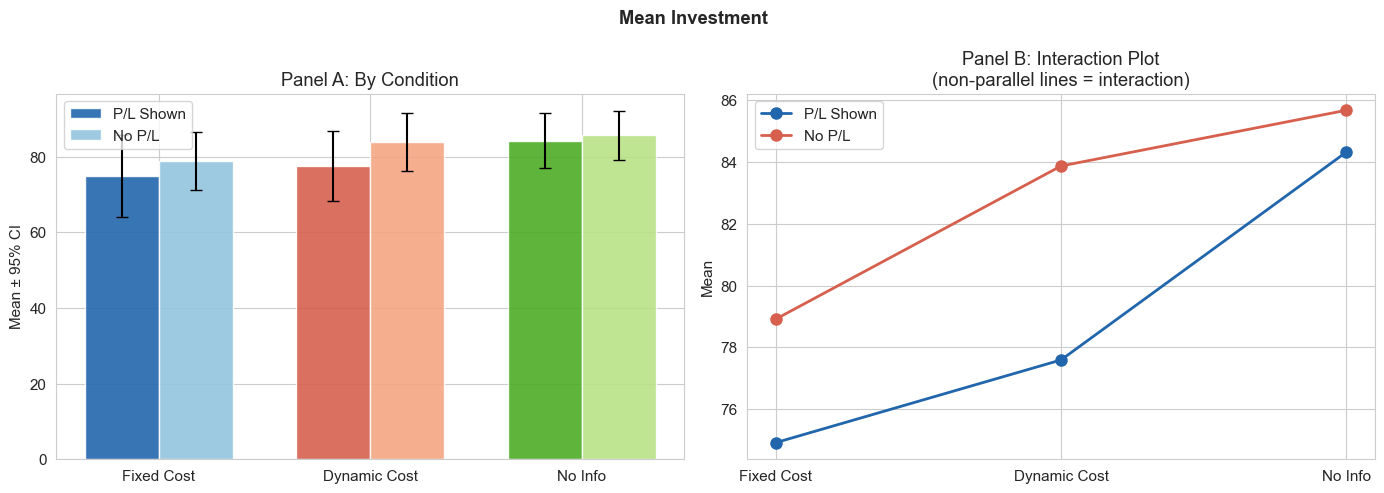

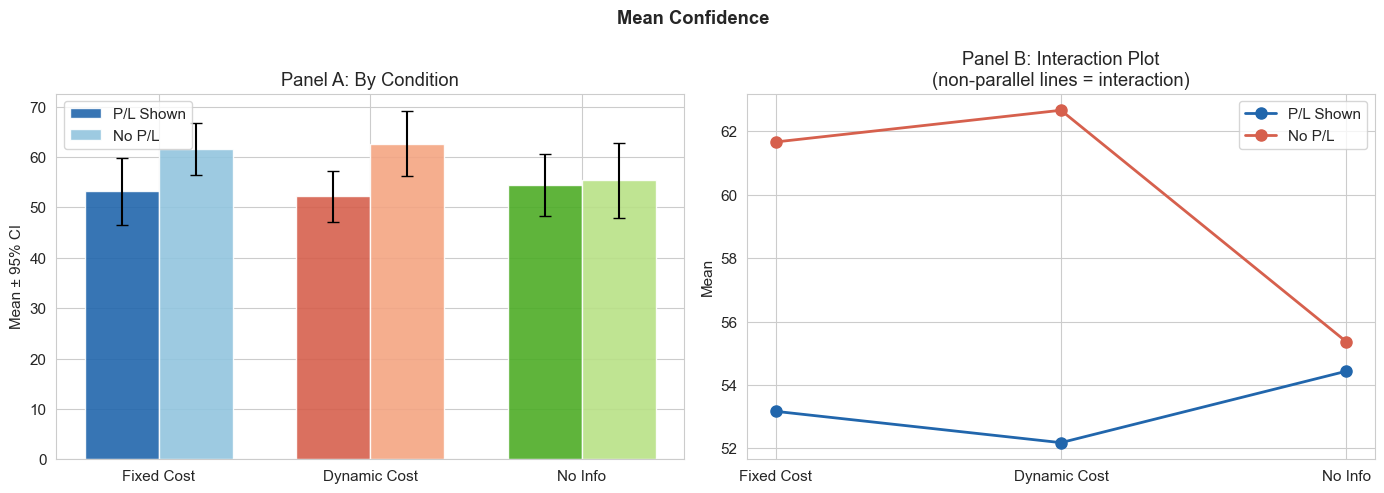

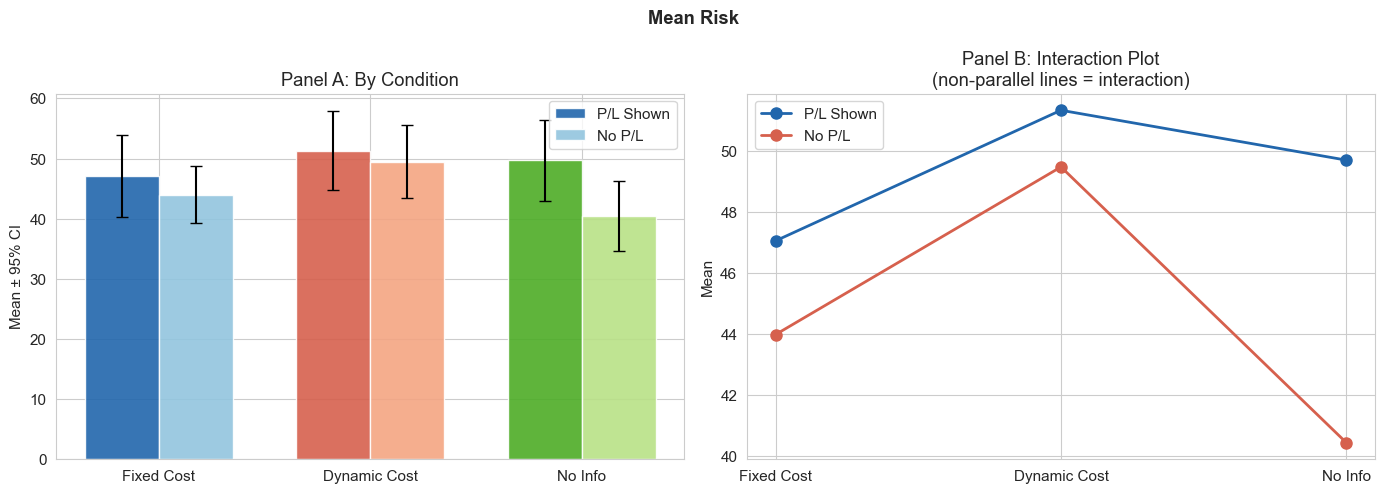

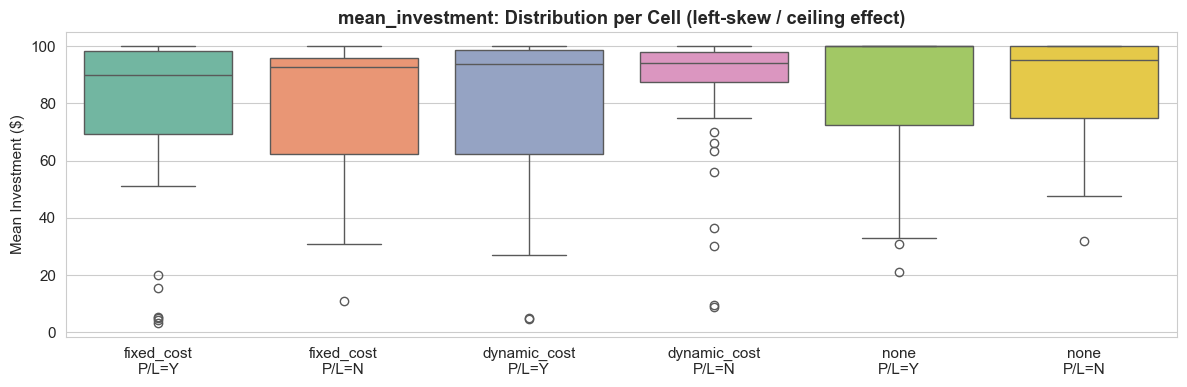

In [15]:
XLABELS = ['Fixed Cost', 'Dynamic Cost', 'No Info']
c_shown = ['#2166AC', '#D6604D', '#4DAC26']
c_not   = ['#92C5DE', '#F4A582', '#B8E186']
x = np.arange(3)
w = 0.35

for dv in DVS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(dv.replace('_', ' ').title(), fontweight='bold')

    sdf = df.groupby(['info_type', 'show_pl'])[dv].agg(['mean', 'sem']).reset_index()
    sdf['ci95'] = sdf['sem'] * 1.96

    # Panel A — grouped bar chart
    ax = axes[0]
    for pl_val, label, cols, offset in [
        (True,  'P/L Shown', c_shown, -w/2),
        (False, 'No P/L',    c_not,    w/2)
    ]:
        sub = sdf[sdf['show_pl'] == pl_val].set_index('info_type').reindex(INFO_ORDER)
        ax.bar(x + offset, sub['mean'], w, yerr=sub['ci95'],
               label=label, color=cols, capsize=4, alpha=0.9, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(XLABELS)
    ax.set_ylabel('Mean ± 95% CI')
    ax.set_title('Panel A: By Condition')
    ax.legend()

    # Panel B — interaction plot
    ax = axes[1]
    cmeans = df.groupby(['info_type', 'show_pl'])[dv].mean().reset_index()
    for pl_val, label, col in [
        (True,  'P/L Shown', '#2166AC'),
        (False, 'No P/L',    '#D6604D')
    ]:
        sub = cmeans[cmeans['show_pl'] == pl_val].set_index('info_type').reindex(INFO_ORDER)
        ax.plot(XLABELS, sub[dv].values, 'o-', label=label, color=col, linewidth=2, markersize=8)
    ax.set_ylabel('Mean')
    ax.set_title('Panel B: Interaction Plot\n(non-parallel lines = interaction)')
    ax.legend()

    plt.tight_layout()
    plt.show()

# Box plot for mean_investment (shows left-skew / ceiling effect that motivated KW)
df['cell_label'] = df.apply(
    lambda r: f"{r['info_type']}\nP/L={'Y' if r['show_pl'] else 'N'}", axis=1
)
cell_order = [f"{it}\nP/L={pl}" for it in INFO_ORDER for pl in ['Y', 'N']]

fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=df, x='cell_label', y='mean_investment', order=cell_order,
            palette='Set2', ax=ax)
ax.set_title('mean_investment: Distribution per Cell (left-skew / ceiling effect)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Mean Investment ($)')
plt.tight_layout()
plt.show()